# 2. Cross-asset relationships (Hypothesis 1)

**Question.** Do changes in Treasury yields, the curve, real yields and implied volatility explain short-term equity returns, and is the relationship stable?

> **Data provenance.** This notebook runs on whichever source the pipeline was given. When the
> source is `SYNTHETIC`, every number below is a property of the simulator in `src/synthetic.py`
> and **not** market history. The only observed market values in the project are the three
> anchors in `config.ANCHORS`. Run `python run_pipeline.py --source fred` on a machine with
> network access to reproduce the identical analysis from live data.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src import backtest, config, features, pipeline, regressions, relative_value, signals

# src.charts selects the Agg backend so the pipeline runs headless; switch back to the
# inline backend afterwards so figures render in the notebook.
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

results = pipeline.run(write_outputs=False)
provenance = results["dataset"].provenance()
print(f"source        {provenance['source']}")
print(f"window        {provenance['start_date']} to {provenance['end_date']}")
print(f"observations  {provenance['daily_observations']:,} trading days")
print(f"validation    {results['validation_log'].summary()}")


source        SYNTHETIC
window        2016-08-15 to 2026-08-13
observations  2,512 trading days
validation    PASS=54


## The specification cannot be estimated as usually written

The natural specification is

$$r_{SPX,t} = \alpha + \beta_1 \Delta y_{2,t} + \beta_2 \Delta y_{10,t} + \beta_3 \Delta Curve_t + \beta_4 \Delta VIX_t + \epsilon_t$$

and it is exactly rank deficient, because $\Delta Curve_t \equiv \Delta y_{10,t} - \Delta y_{2,t}$. The design matrix is singular, so the individual coefficients are not identified. Estimating it anyway and reading the condition number is the fastest way to see the problem.

In [2]:
features_frame = results["features"]
rows = []
for name, regressors in regressions.SPECIFICATIONS.items():
    _, diagnostics = regressions.fit_ols(features_frame, regressors, label=name)
    rows.append(diagnostics)
diag = pd.DataFrame(rows).set_index("spec")
diag[["nobs", "r_squared", "adj_r_squared", "condition_number", "max_vif", "rank_deficient"]]

,nobs,r_squared,adj_r_squared,condition_number,max_vif,rank_deficient
spec,,,,,,
naive,2511,0.3971,0.3964,inf,inf,True
slope,2511,0.3971,0.3964,70.8175,1.2231,False
real,2511,0.4406,0.4397,73.6657,2.3210,False


The `naive` and `slope` specifications have identical R-squared because they span the same space; only `slope` has identified coefficients. The `real` specification uses the Fisher decomposition $y_{10} = r_{10} + \pi_{10}$ to separate a discount-rate shock from an inflation-expectations shock, which raises explanatory power because the two have opposite signs for equities.

In [3]:
coefficients = results["h1_coefficients"]
coefficients[coefficients["spec"] == "real"][["term", "coefficient", "std_error_hac", "t_stat", "p_value", "nobs"]]

,term,coefficient,std_error_hac,t_stat,p_value,nobs
9,const,0.0006,0.0002,3.4025,0.0007,2511
10,dy_1d_real10,-0.0006,0.0001,-8.7406,0.0000,2511
11,dy_1d_breakeven10,0.0003,0.0001,2.6724,0.0075,2511
12,dy_1d_slope,0.0004,0.0001,4.7603,0.0000,2511
13,ret_1d_vix,-0.0721,0.0049,-14.6028,0.0000,2511


## Why HAC standard errors

Breusch-Pagan rejects homoskedasticity and Ljung-Box rejects zero residual autocorrelation, so ordinary standard errors would be too small and every t-statistic too flattering. Newey-West with the standard $\lfloor 4(n/100)^{2/9} \rfloor$ bandwidth is used throughout.

In [4]:
diag[["hac_lags", "durbin_watson", "breusch_pagan_p", "ljung_box_p_10", "residual_skew", "residual_kurtosis"]]

,hac_lags,durbin_watson,breusch_pagan_p,ljung_box_p_10,residual_skew,residual_kurtosis
spec,,,,,,
naive,8,1.8871,0.0000,0.0000,0.3252,4.1037
slope,8,1.8871,0.0000,0.0000,0.3252,4.1037
real,8,1.9059,0.0000,0.0004,0.2253,3.2711


## Is the relationship stable?

This is the part full-sample coefficients hide.

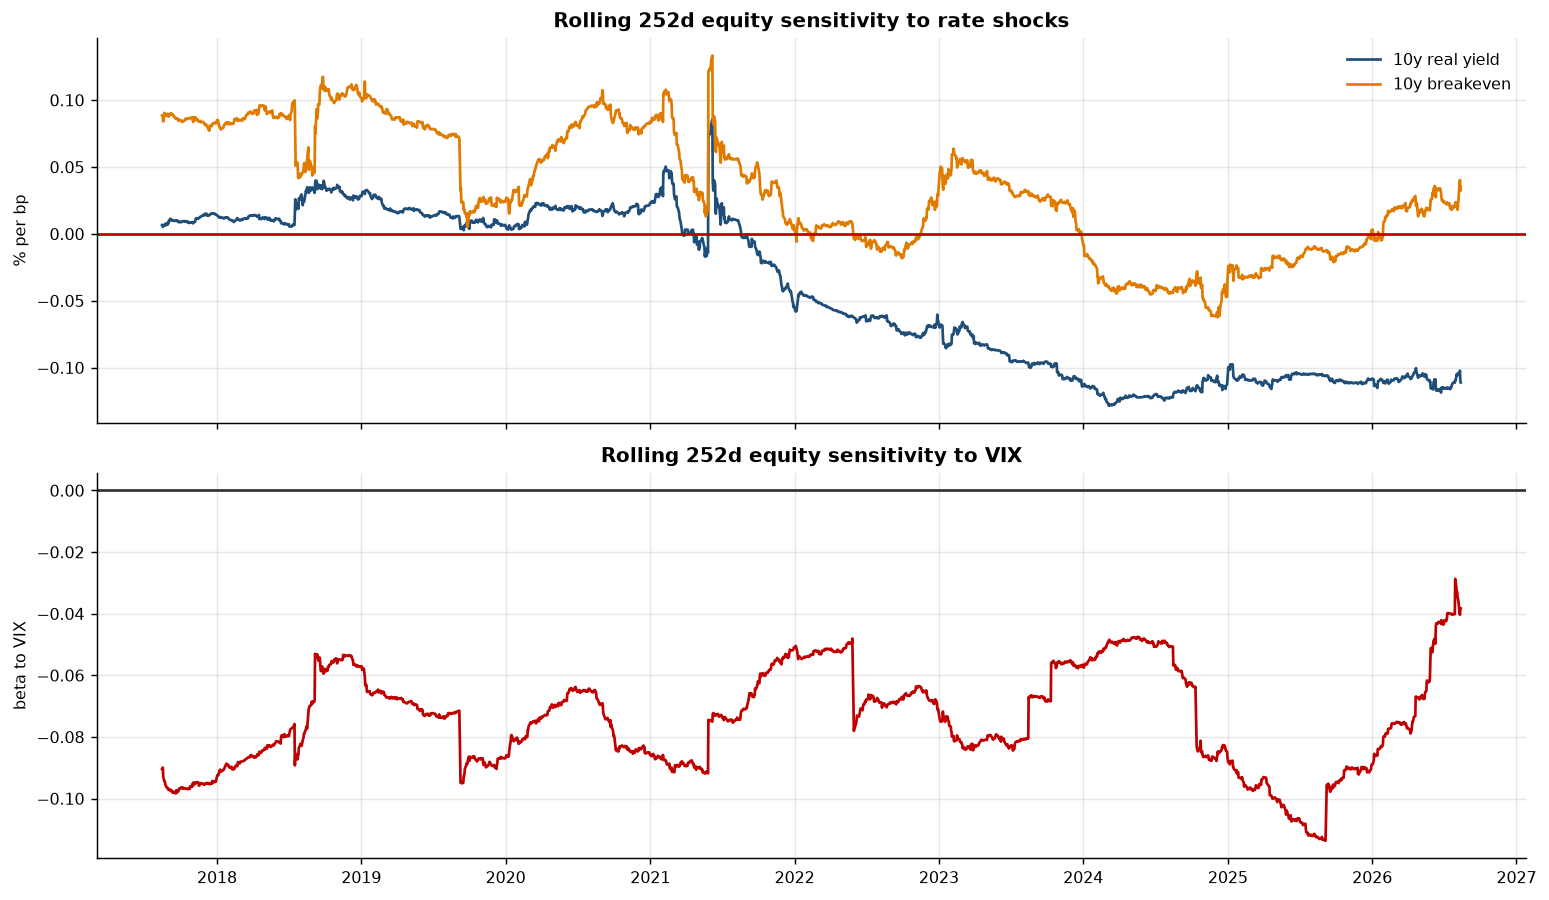

,spec,term,mean,std,min,max,share_positive,sign_stable,windows
0,real,dy_1d_real10,-0.0004,0.0006,-0.0013,0.0009,0.4332,False,2260
1,real,dy_1d_breakeven10,0.0003,0.0005,-0.0006,0.0013,0.7150,False,2260
2,real,dy_1d_slope,0.0003,0.0004,-0.0008,0.0012,0.6978,False,2260
3,real,ret_1d_vix,-0.0743,0.0162,-0.1137,-0.0287,0.0000,True,2260


In [5]:
rolling = results["h1_rolling_betas"]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(rolling.index, rolling["beta_dy_1d_real10"] * 100, label="10y real yield", color="#1f4e79")
axes[0].plot(rolling.index, rolling["beta_dy_1d_breakeven10"] * 100, label="10y breakeven", color="#e07b00")
axes[0].axhline(0, color="#c00000"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylabel("% per bp"); axes[0].set_title("Rolling 252d equity sensitivity to rate shocks")
axes[1].plot(rolling.index, rolling["beta_ret_1d_vix"], color="#c00000")
axes[1].axhline(0, color="#333333"); axes[1].grid(alpha=0.3)
axes[1].set_ylabel("beta to VIX"); axes[1].set_title("Rolling 252d equity sensitivity to VIX")
plt.tight_layout(); plt.show()

results["h1_stability"]

The VIX coefficient never changes sign. The real-yield coefficient does, which means the full-sample estimate is averaging over two different regimes rather than measuring one structural relationship.

## Explanatory power is not predictive power

`contemporaneous` fits on the training split and measures R-squared on later splits with same-day regressors: it tests whether the relationship is stable. It is not tradable, because same-day yield and VIX changes are not known when the equity return is realised. `predictive` lags every regressor one day, which is the version you could actually trade.

In [6]:
results["h1_out_of_sample"]

,mode,spec,split,nobs,r_squared,sign_accuracy,correlation
0,contemporaneous,real,train,1605,0.4536,0.7433,0.6735
1,contemporaneous,real,validation,502,0.3831,0.7271,0.6209
2,contemporaneous,real,test,404,0.2070,0.6733,0.4563
3,predictive,real,train,1604,0.0064,0.5237,0.0802
4,predictive,real,validation,502,-0.0115,0.5259,-0.0347
5,predictive,real,test,404,-0.0094,0.4950,-0.0218


**Conclusion.** Hypothesis 1 is a strong contemporaneous relationship with correct signs and no forecasting content. Reporting the contemporaneous R-squared as though it were predictive would be the single most misleading thing this project could do.

## Rolling correlations across the cross-asset set

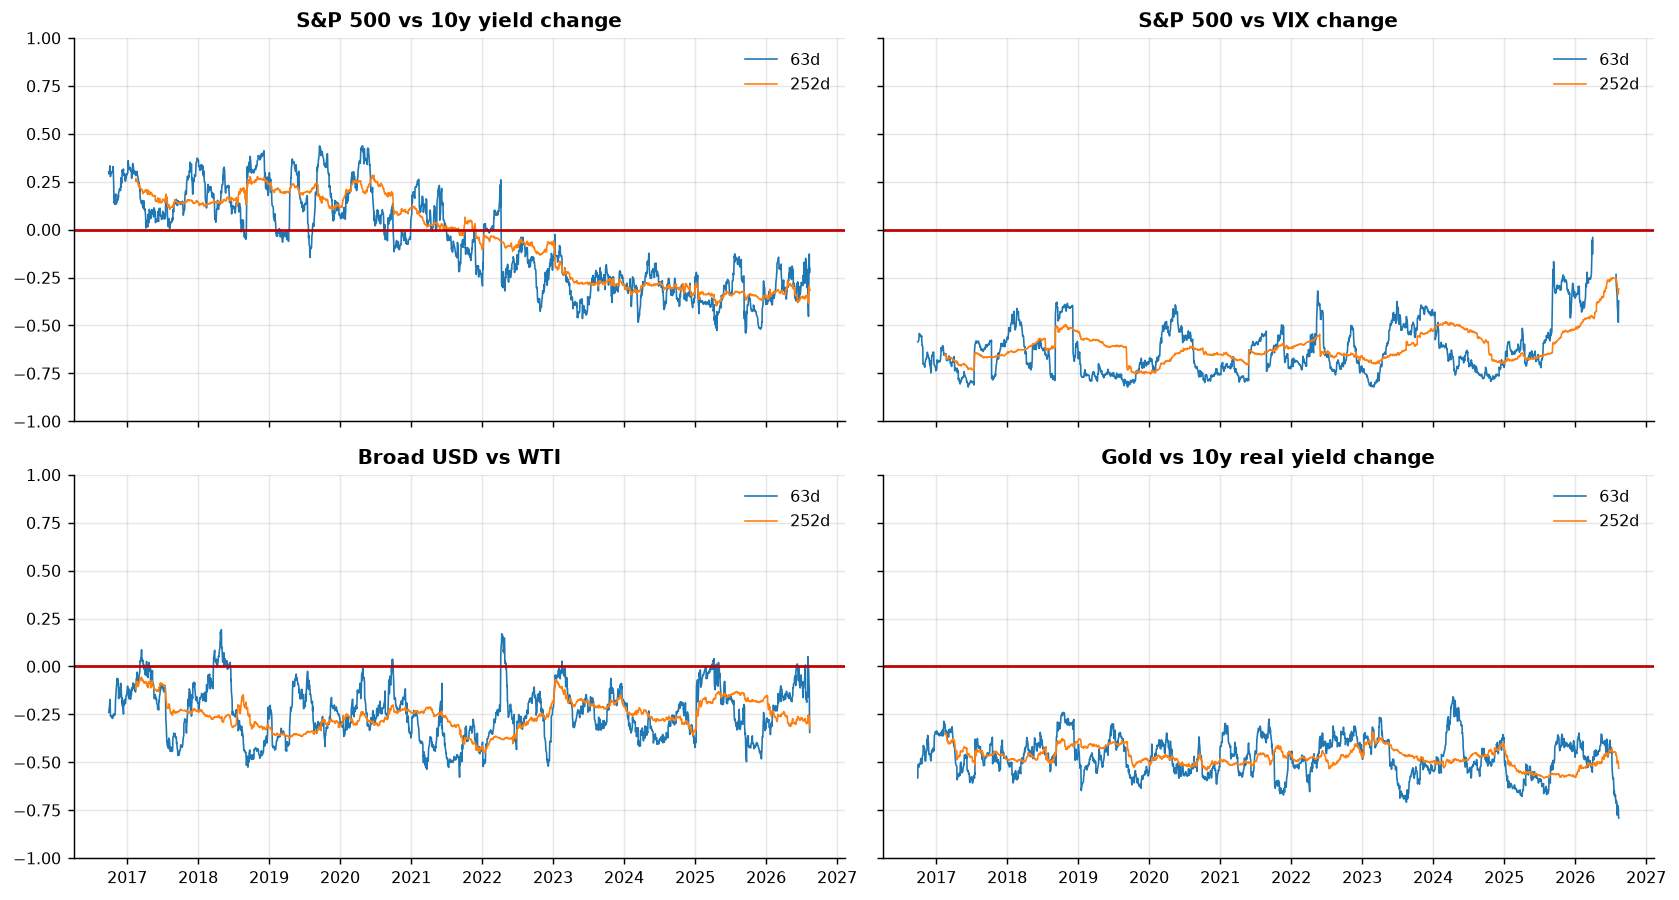

In [7]:
rolling_rel = results["rolling_relationships"]
panels = [("equity_vs_rates", "S&P 500 vs 10y yield change"),
          ("equity_vs_vix", "S&P 500 vs VIX change"),
          ("usd_vs_wti", "Broad USD vs WTI"),
          ("gold_vs_real", "Gold vs 10y real yield change")]
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for ax, (key, title) in zip(axes.ravel(), panels):
    for window in config.ROLLING_CORR_WINDOWS:
        ax.plot(rolling_rel.index, rolling_rel[f"corr{window}_{key}"], linewidth=0.9, label=f"{window}d")
    ax.axhline(0, color="#c00000"); ax.set_ylim(-1, 1); ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()